In [1]:
from dotenv import load_dotenv
import operator
from langchain_groq import ChatGroq
from typing import TypedDict,List,Literal
from pydantic import Field,BaseModel
from langchain_core.messages import AIMessage,SystemMessage,HumanMessage
from langgraph.graph import START,END,StateGraph
from langgraph.types import Command,interrupt # to implement the concept of human in the loop
from langchain_core.tools import tool
import requests
from tavily import TavilyClient

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq( model="llama-3.1-8b-instant",)

## State of Workflow

In [29]:
class State(TypedDict):
    user_msg: str
    topic:str
    needs_classification: bool
    knowledge_level : str
    llm_description: str

## Schema of understand topic node

In [5]:
class understandtopic(BaseModel):
    topic: str
    knowledge_level :  Literal["beginner" ,"intermediate","advanced"]
    needs_classification: bool = Field(description= "True if topic is unclear, False if clear")

## Structured LLM

In [6]:
struc_model= model.with_structured_output(understandtopic,strict = True)

## Understand topic Node

In [7]:
topic_msg = """You are the first node in an AI Study Buddy pipeline.

Your job is to analyze the user's study request and extract structured information from it.

Given the user's message, you must determine:
1. The main topic they want to study (e.g. "Python decorators", "Newton's laws", "LangGraph nodes")
2. Their apparent knowledge level based on how they asked:
   - "beginner" — they used simple language, asked "what is", or seem unfamiliar
   - "intermediate" — they know basics, asking "how does X work" or "difference between"
   - "advanced" — they used technical terms, asking about internals or edge cases
3. Whether the topic is clear enough to proceed or needs clarification:
   - "clear" — you know exactly what to study and can search for it
   - "unclear" — the request is too vague, ambiguous, or missing context"""
def understandtopic_node(state:State)->dict:
    message = state['user_msg']
    output = struc_model.invoke([
        SystemMessage(content=topic_msg),
        HumanMessage(content=message)
    ])

    return {'topic': output.topic,'knowledge_level': output.knowledge_level,'needs_classification': bool(output.needs_classification)}

## Router Function

In [8]:
def router(state:State)->Literal['clarify_with_human','search_agent']:
    clearification = state['needs_classification']
    if clearification == True:
        return 'clarify_with_human'
    else:
        return 'search_agent'


## clarify_with_human node

In [9]:
def clarify_with_human(state: State):
    decision = interrupt(
        {
            "question": f"Aap '{state['topic']}' kis level pe seekhna chahti hain?",
            "options": ["Beginner", "Intermediate", "Advanced"],
            "user_msg": state["user_msg"]
        }
    )
    return {
        "knowledge_level": decision  # 👈 user ka answer yahan store hoga
    }

## search_agent (sub-graph)

### subgraph state

In [10]:
class sub_graph_state(TypedDict):
    user_msg:str
    topic: str
    knowledge_level: Literal["beginner" ,"intermediate","advanced"]
    response: str
    action: Literal['tool_node','llm_node']


### decision node schema

In [11]:
class decisionschema(BaseModel):
    action: Literal['tool_node','llm_node']
    
    

### structured LLM for decision making 

In [12]:
struc_decision_model= model.with_structured_output(decisionschema,strict = True)

### Defining Decision Node

In [13]:
def decision_node(state: sub_graph_state) -> dict:
    decision_msg = f"""
You are a decision agent.

User query: {state['user_msg']}
Topic: {state['topic']}
Knowledge Level: {state['knowledge_level']}

Decide:
- If external knowledge/API needed → tool
- If you can answer directly → llm

Return structured output only.
"""
    output = struc_decision_model.invoke(
        [SystemMessage(content = decision_msg),
         HumanMessage(content= "answer it.")]
    )
    print(output.action)
    return {**state,'action': output.action}
    

### Subgraph Router Node

In [14]:
def sub_router(state:sub_graph_state) -> Literal['tool_node','llm_node']:
    dec = state['action']
    if dec =='tool':
        return 'tool_node'
    else:
        return 'llm_node'
    

### Defining tools

#### 1-Wikepidea

In [15]:
@tool
def wikepedia_search_node(topic:str) -> dict:
    """
    Fetch a short summary of a topic from Wikipedia.
    Use this when factual or definition-based information is needed.
    """
    
    url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{topic}"
    r = requests.get(url)
    return r.json().get("extract", "")

#### 2-Tavily serach 

In [16]:
def tavily_search_tool(topic,depth)->dict:
    
    
    result = TavilyClient.search(
         query=topic,
        search_depth=depth,
        max_results=1
    )
    return result

### Making LLM tool aware

In [17]:
tools = [wikepedia_search_node]
tool_llm= model.bind_tools(tools) 

### Defining Tool Node

In [18]:
def search_node(state: sub_graph_state) -> dict:
    topic = state['topic']
    knowledgeLevel = state['knowledge_level']
    if knowledgeLevel == "beginner":
        data = wikepedia_search_node(topic)
    else:
        data = tavily_search_tool(topic,knowledgeLevel)
    
    response = model.invoke([
        SystemMessage(content="Explain clearly based on data"),
        HumanMessage(content=data)
    ])
    return {'res': response.content}



### Defining LLM Search node

In [19]:
search_msg ="You are Student assistant. Explain the Given topic by user accordin to the required knowledge depth"
def llm_search(state: sub_graph_state) -> dict:
    topic = state['topic']
    knowledgedepth = state['knowledge_level']
    response = model.invoke([
        SystemMessage(content=search_msg),
        HumanMessage(content=f'topic-{topic}.... knowledgedepth - {knowledgedepth}')
    ])
    return {'res': response.content}

### Creating subgraph

In [20]:
sub_graph = StateGraph(sub_graph_state)

## Adding Nodes
sub_graph.add_node('Decision Node',decision_node)
sub_graph.add_node('tool_node',search_node)
sub_graph.add_node('llm_node',llm_search)

## Adding Edges
sub_graph.add_edge(START,'Decision Node')
sub_graph.add_conditional_edges('Decision Node',sub_router)
sub_graph.add_edge('tool_node',END)
sub_graph.add_edge('llm_node',END)

sub_workflow = sub_graph.compile()

In [21]:
print(sub_graph_state['action'])

__main__.sub_graph_state['action']


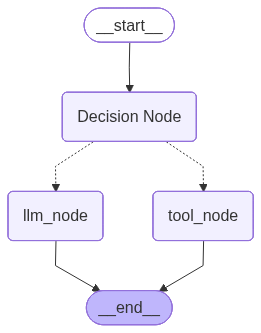

In [112]:
sub_workflow

In [28]:
# Execute the graph
initial_state = {
    'user_msg':'I am learning LAngGraph and python functions along with the concept of OOP kya tum meri madad kr skty ho is mein Please use tools that are bind with LLM',
    'knowledge_level': "advanced",
    'topic':'LangGraph'
     

}
sub_workflow.invoke(initial_state)


llm_node


{'user_msg': 'I am learning LAngGraph and python functions along with the concept of OOP kya tum meri madad kr skty ho is mein Please use tools that are bind with LLM',
 'topic': 'LangGraph',
 'knowledge_level': 'advanced',
 'action': 'llm_node'}

## Search Agent Node

In [30]:
def search_agent(state:State):
    msg = state['user_msg']
    knowledge = state['knowledge_level']
    topic = state['topic']

    result = sub_workflow.invoke({'user_msg': msg,'topic': topic,'knowledge_level': knowledge})
    return({'llm_description': result['response']})

## Creating Graph

In [71]:
graph = StateGraph(State)

## Adding Nodes
graph.add_node('Understand_topic',understandtopic_node)
graph.add_node('clarify_with_human',clarify_with_human)
graph.add_node('search_agent',search_agent)

## Add Edges
graph.add_edge(START,'Understand_topic')
graph.add_conditional_edges('Understand_topic',router)
graph.add_edge('clarify_with_human',END)
graph.add_edge('search_agent',END)

# Graph compilation
workflow = graph.compile()

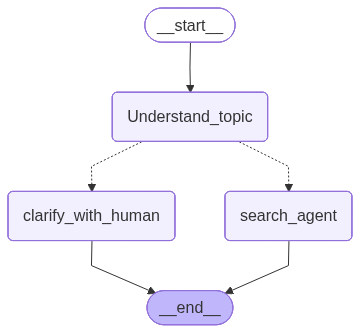

In [32]:
workflow

In [75]:
# Execute the graph
initial_state = {
    'user_msg':'I am learning LAngGraph and puthon functions kya tum meri madad kr skty ho is mein'

}
workflow.invoke(initial_state)


{'user_msg': 'I am learning LAngGraph and puthon functions kya tum meri madad kr skty ho is mein',
 'topic': 'LangGraph and python functions',
 'needs_classification': True,
 'knowledge_level': 'beginner',
 '__interrupt__': [Interrupt(value={'question': "Aap 'LangGraph and python functions' kis level pe seekhna chahti hain?", 'options': ['Beginner', 'Intermediate', 'Advanced'], 'user_msg': 'I am learning LAngGraph and puthon functions kya tum meri madad kr skty ho is mein'}, id='deba4f1afb99c3ac67da4cae54b44705')]}